## INITIALIZATION

In [1]:
# -----------------------------------------------------------------------------
# INITIALIZATION
# -----------------------------------------------------------------------------
import sys
print(f"Python version: {sys.version}")
import seaborn as sns
import matplotlib.pyplot as plt

import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce

import pyspark
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/07/03 13:37:20 WARN Utils: Your hostname, Charles.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.153 instead (on interface en0)
25/07/03 13:37:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/03 13:37:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/07/03 13:37:21 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/07/03 13:37:21 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/07/03 13:37:21 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/07/03 13:37:21 WARN Utils: 

In [3]:
dx_cols = [col for col in df_claims.columns if col.__contains__("DX")]


# Step 2: Create CKD_STAGE using dynamic matching
def build_ckd_stage_case(dx_cols):
    stage_expr = None
    stage_map = {
        "N181": "CKD Stage 1",
        "N182": "CKD Stage 2",
        "N183": "CKD Stage 3",
        "N184": "CKD Stage 4",
        "N185": "CKD Stage 5",
        "N186": "ESRD",
        "N189": "Unspecified"
    }

    for code, label in stage_map.items():
        # Create a compound OR condition over all DX columns for each code
        condition = reduce(lambda a, b: a | b, [F.col(c).startswith(code) for c in dx_cols])
        if stage_expr is None:
            stage_expr = F.when(condition, label)
        else:
            stage_expr = stage_expr.when(condition, label)
    
    return stage_expr

# Step 3: Filter for CKD codes and extract stage
ckd_filter = reduce(lambda a, b: a | b, [F.col(c).startswith("N18") for c in dx_cols])

df_ckd_claims = (
    df_claims
    .filter(ckd_filter)
    .withColumn("CKD_STAGE", build_ckd_stage_case(dx_cols))
    .filter(F.col("CKD_STAGE").isNotNull())
    .filter(F.col("SVCDATE").isNotNull())
)


## 07/03 Distribution of total claim costs per enrollee over annual period 

e.g. one patient’s cumulative cost across all their claims, or just CKD-related ones.

In [27]:
# Step 1: Total CKD-related cost per enrollee per year
df_ckd_annual_costs = (
    df_ckd_claims
    .groupBy("ENROLID", "YEAR", "CKD_STAGE")
    .agg(F.sum("NETPAY").alias("ckd_annual_cost"))
)

# Step 2: Average annual cost by CKD stage and year
df_ckd_annual_avg = (
    df_ckd_annual_costs
    .groupBy("CKD_STAGE", "YEAR")
    .agg(F.mean("ckd_annual_cost").alias("avg_ckd_annual_cost"))
    .orderBy("YEAR", "CKD_STAGE")
)

df_ckd_annual_avg_pd = df_ckd_annual_avg.toPandas()


In [24]:
# Step 1: Total all-claims cost per enrollee per year
df_all_annual_costs = (
    df_claims
    .join(df_ckd_claims.select("ENROLID", "CKD_STAGE").distinct(), on="ENROLID", how="inner")
    .filter(F.col("YEAR").isin([2017, 2018, 2019]))
    .groupBy("ENROLID", "YEAR", "CKD_STAGE")
    .agg(F.sum("NETPAY").alias("all_annual_cost"))
)

# Step 2: Average annual cost by CKD stage and year
df_all_annual_avg = (
    df_all_annual_costs
    .groupBy("CKD_STAGE", "YEAR")
    .agg(F.mean("all_annual_cost").alias("avg_all_annual_cost"))
    .orderBy("YEAR", "CKD_STAGE")
)

df_all_annual_avg_pd = df_all_annual_avg.toPandas()


In [35]:
df_ckd_annual_costs_pd = df_ckd_annual_costs.toPandas()


# Compute 99th percentile per CKD_STAGE and YEAR
quantiles = (
    df_ckd_annual_costs_pd
    .groupby(["CKD_STAGE", "YEAR"])["ckd_annual_cost"]
    .quantile(0.99)
    .reset_index()
    .rename(columns={"ckd_annual_cost": "cap"})
)

# Merge caps back to original
df_trimmed = df_ckd_annual_costs_pd.merge(
    quantiles,
    on=["CKD_STAGE", "YEAR"],
    how="left"
)

# Filter outliers within each stage-year group
df_trimmed = df_trimmed[df_trimmed["ckd_annual_cost"] <= df_trimmed["cap"]]



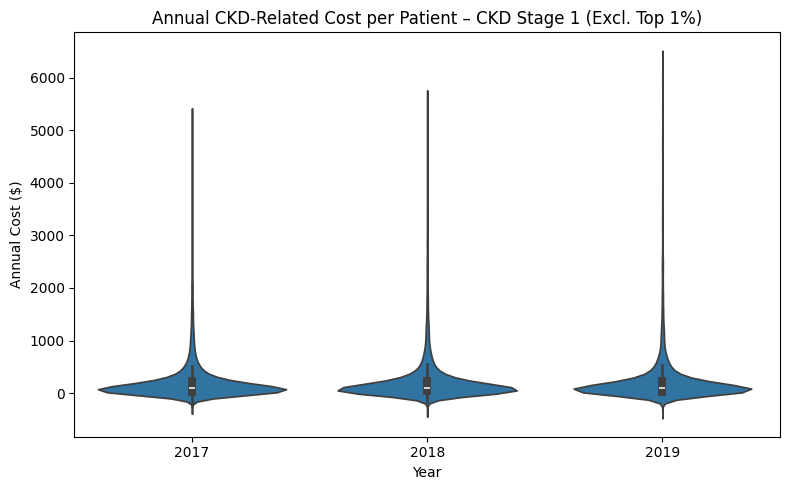

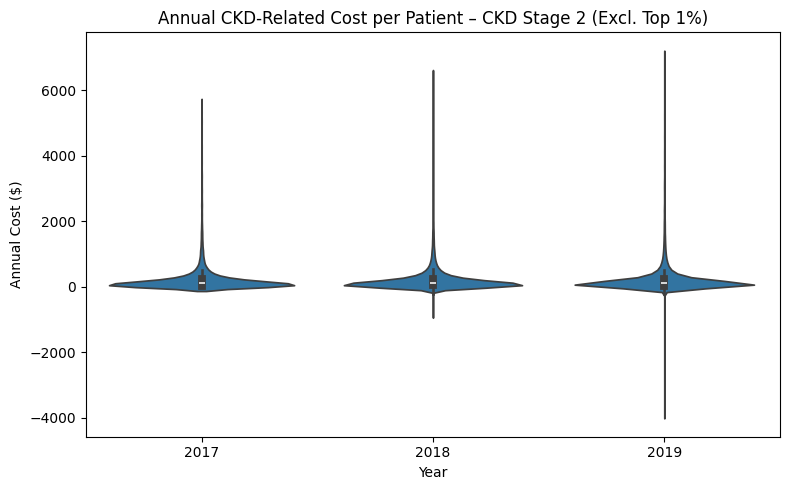

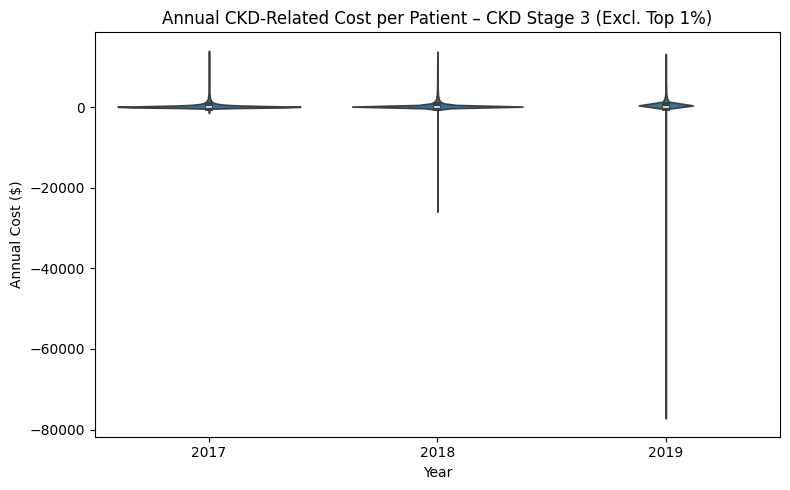

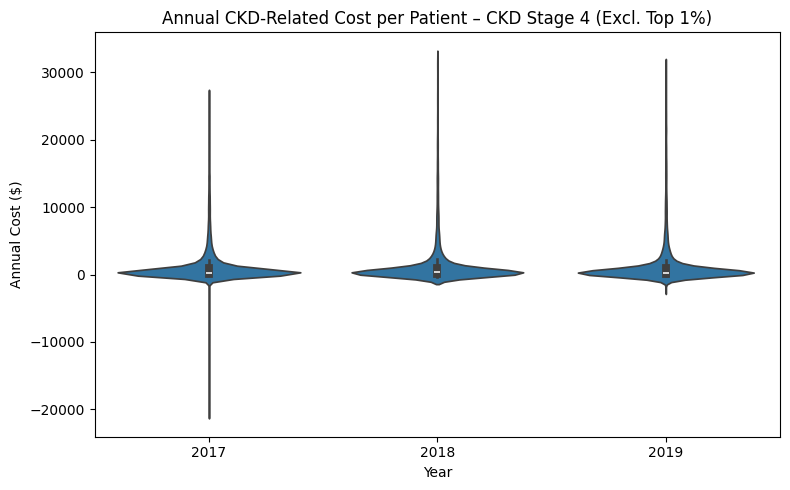

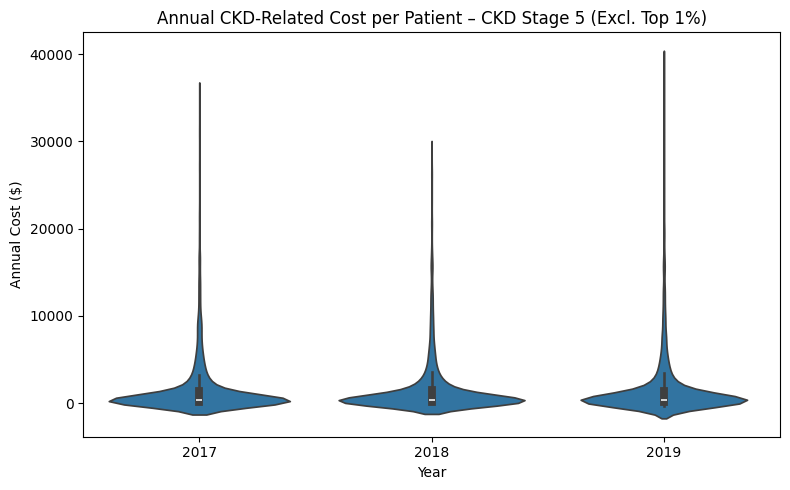

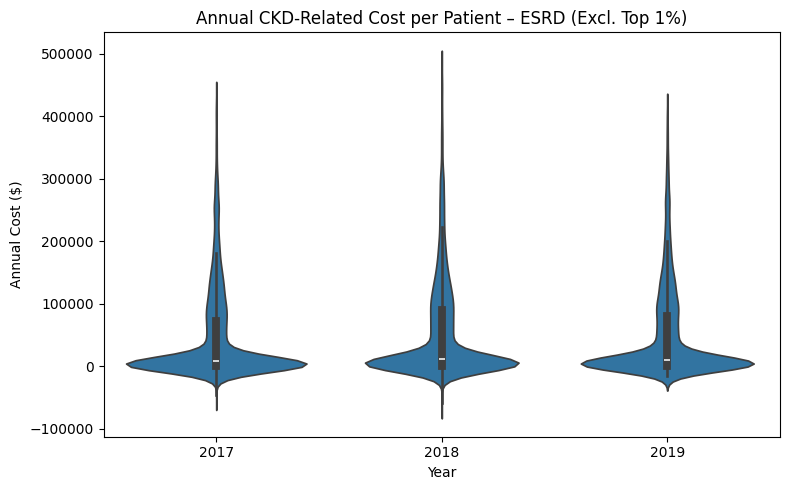

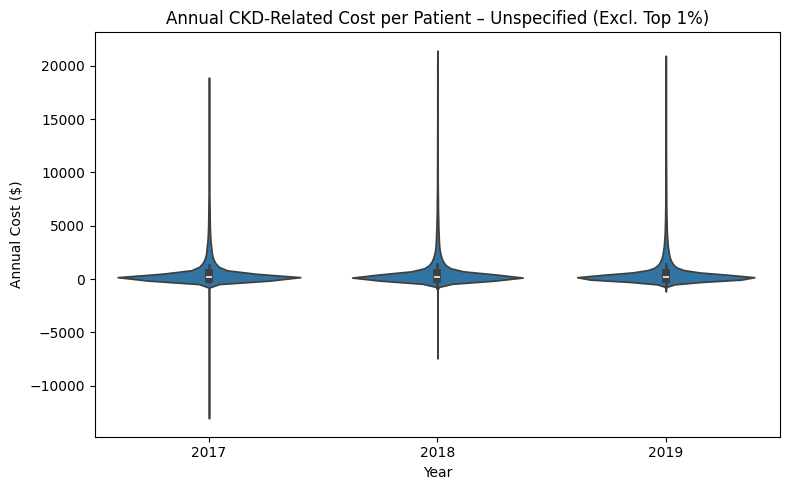

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

unique_stages = df_trimmed["CKD_STAGE"].unique()

# Sort stages in clinical order if needed
stage_order = [
    "CKD Stage 1", "CKD Stage 2", "CKD Stage 3", 
    "CKD Stage 4", "CKD Stage 5", "ESRD", "Unspecified"
]
unique_stages = [s for s in stage_order if s in unique_stages]

# Create a plot for each stage
for stage in unique_stages:
    stage_data = df_trimmed[df_trimmed["CKD_STAGE"] == stage]
    
    plt.figure(figsize=(8, 5))
    sns.violinplot(
        data=stage_data,
        x="YEAR",
        y="ckd_annual_cost",
        inner="box"
    )
    plt.title(f"Annual CKD-Related Cost per Patient – {stage} (Excl. Top 1%)")
    plt.ylabel("Annual Cost ($)")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.show()


🔹 Option 2: Clip extreme outliers (e.g. above 99th percentile)

When plotting with extremely skewed data (like your cost distribution where max ≈ $7 million but 25% is under $7K), KDE plots collapse into a narrow band near zero, making the axis look like it's stuck at 0–1 or very small values.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_total_annual_costs_pd = df_all_annual_costs.toPandas()

# Step 1: Filter CKD and total claim data to 2018 only
df_ckd_2018 = df_ckd_annual_costs_pd[df_ckd_annual_costs_pd["YEAR"] == 2018].copy()
df_total_2018 = df_total_annual_costs_pd[df_total_annual_costs_pd["YEAR"] == 2018].copy()


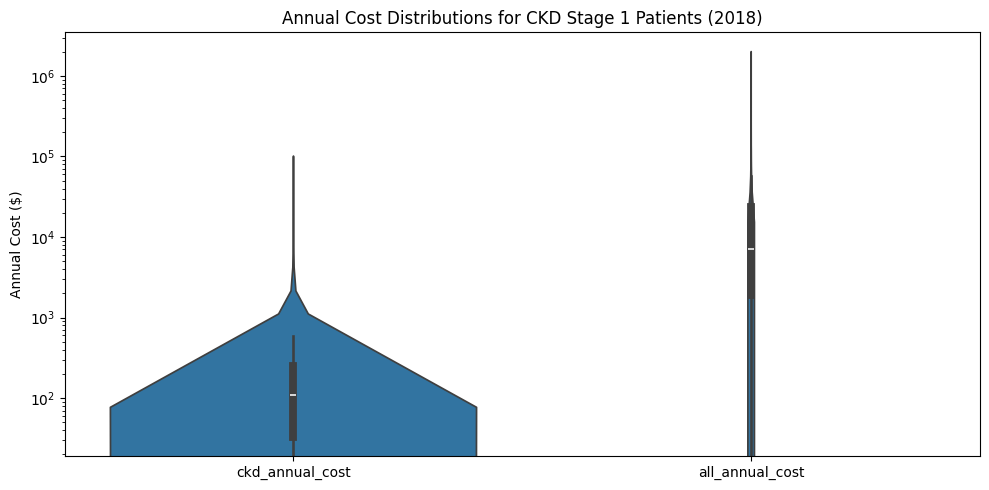

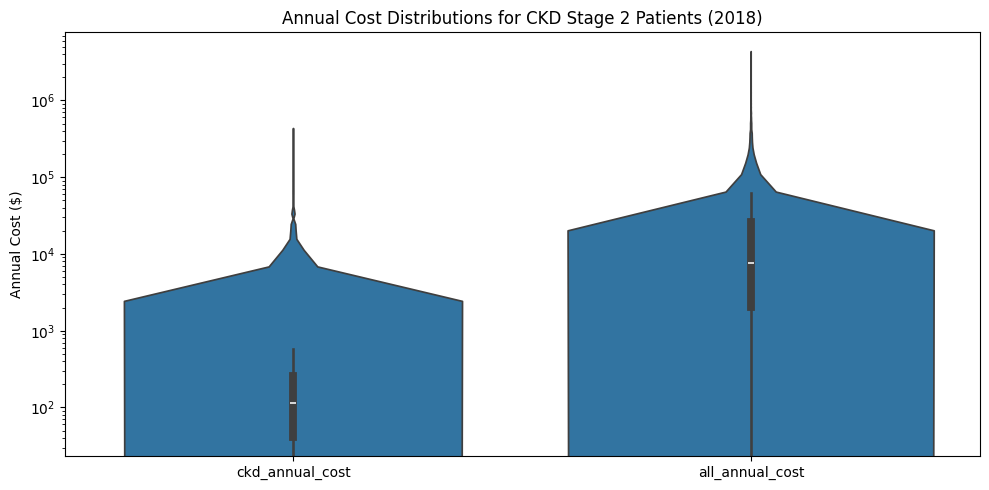

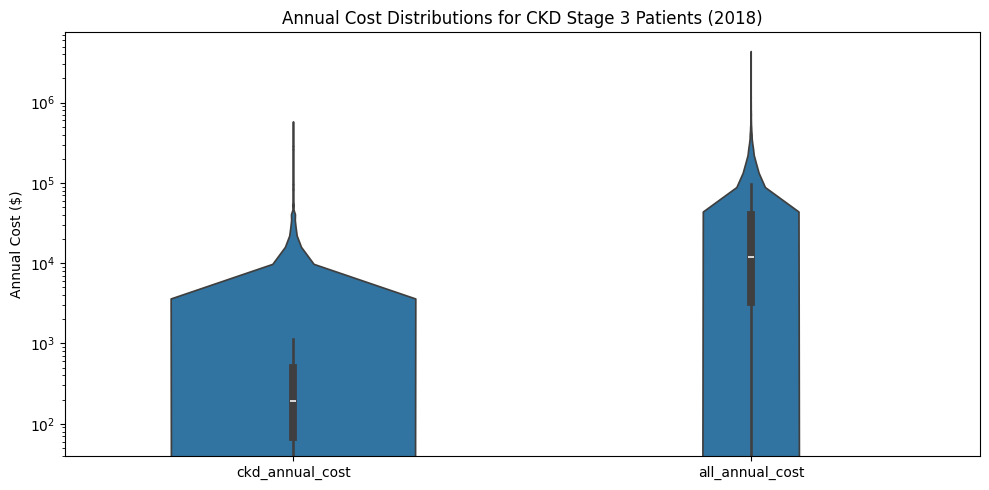

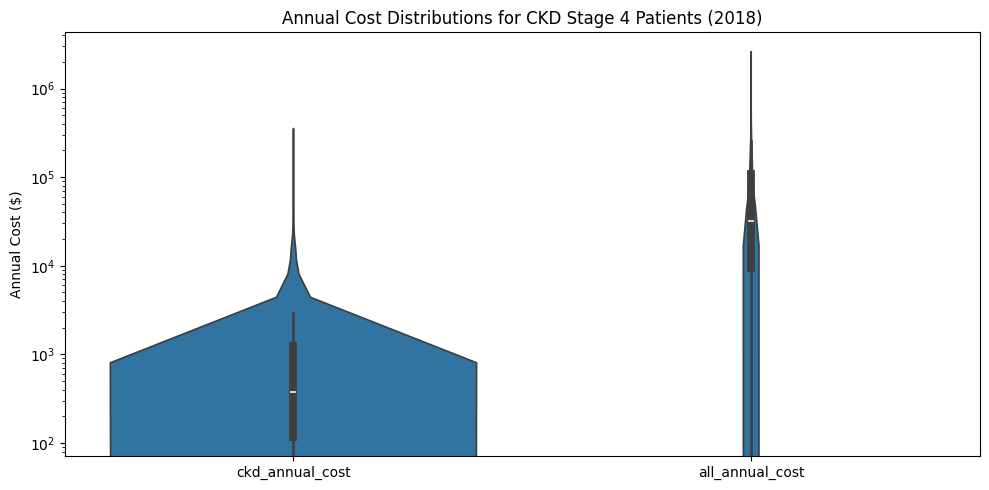

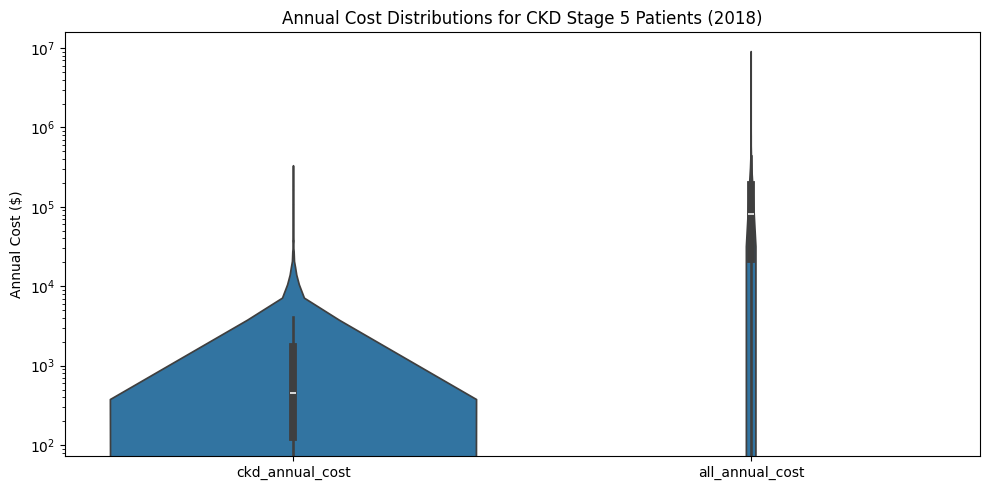

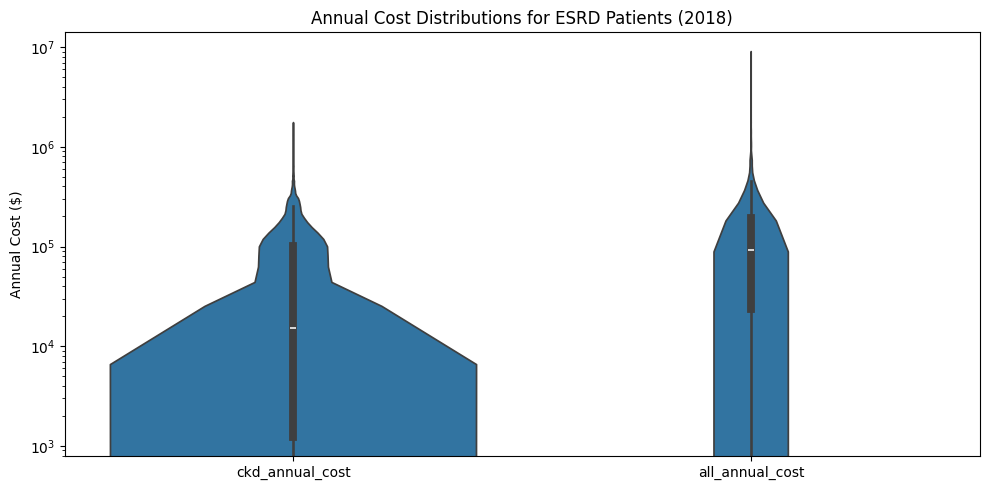

In [42]:

# Step 2: Merge both datasets on ENROLID and CKD_STAGE
df_compare = pd.merge(
    df_ckd_2018[["ENROLID", "CKD_STAGE", "ckd_annual_cost"]],
    df_total_2018[["ENROLID", "all_annual_cost"]],
    on="ENROLID",
    how="inner"
)

# Optional: filter out "Unspecified" or invalid stages
valid_stages = ["CKD Stage 1", "CKD Stage 2", "CKD Stage 3", "CKD Stage 4", "CKD Stage 5","ESRD"]
df_compare = df_compare[df_compare["CKD_STAGE"].isin(valid_stages)]

# Step 3: Melt to long format for easier plotting
df_long = df_compare.melt(
    id_vars=["ENROLID", "CKD_STAGE"],
    value_vars=["ckd_annual_cost", "all_annual_cost"],
    var_name="Cost_Type",
    value_name="Annual_Cost"
)

# Step 4: Plot per CKD stage
for stage in valid_stages:
    plt.figure(figsize=(10, 5))
    sns.violinplot(
        data=df_long[df_long["CKD_STAGE"] == stage],
        x="Cost_Type",
        y="Annual_Cost",
        inner="box"
    )
    plt.title(f"Annual Cost Distributions for {stage} Patients (2018)")
    plt.ylabel("Annual Cost ($)")
    plt.xlabel("")
    plt.yscale("log")  # Helps with heavy skew
    plt.tight_layout()
    plt.show()


## Quarterly Cost Evolution per enrollee by stage 

In [6]:
from pyspark.sql.functions import year, quarter

df_ckd_quarterly = (
    df_ckd_claims
    .withColumn("YEAR", year("SVCDATE"))
    .withColumn("QUARTER", quarter("SVCDATE"))
    .filter(F.col("YEAR").isin([2017, 2018, 2019]))
)
df_stage_2017 = (
    df_ckd_quarterly
    .filter(F.col("YEAR") == 2017)
    .select("ENROLID", "CKD_STAGE")
    .dropDuplicates(["ENROLID"])
    .withColumnRenamed("CKD_STAGE", "stage_2017")
)


df_with_stage = df_ckd_quarterly.join(df_stage_2017, on="ENROLID", how="inner")



In [ ]:
#To count how many CKD-related claims there are per enrollee in the 
# dataframe
df_enrollee_claim_counts = (
    df_with_stage
    .groupBy("ENROLID","stage_2017")
    .agg(F.count("*").alias("n_ckd_claims"))
    .orderBy(F.desc("n_ckd_claims"))
)
df_enrollee_claim_counts.show()

+-----------+-----------+------------+
|    ENROLID| stage_2017|n_ckd_claims|
+-----------+-----------+------------+
| 3479003901|       ESRD|        7484|
| 1362437802|       ESRD|        6223|
| 2402582901|       ESRD|        6121|
| 1497700702|       ESRD|        5853|
|  139583201|       ESRD|        5666|
|33232099901|       ESRD|        5142|
|33063516201|CKD Stage 4|        5021|
|  764732902|       ESRD|        4851|
| 4253274702|       ESRD|        4586|
|  260968302|       ESRD|        4477|
|  138173501|       ESRD|        4441|
|  136500501|       ESRD|        4331|
| 3993912901|       ESRD|        4310|
| 4278699301|       ESRD|        4305|
| 3630388002|       ESRD|        4243|
| 1137622302|Unspecified|        4233|
| 3200759301|       ESRD|        4105|
| 3673124204|       ESRD|        4100|
|  139659201|       ESRD|        4069|
| 2535480702|       ESRD|        4067|
+-----------+-----------+------------+
only showing top 20 rows


In [24]:
from pyspark.sql.functions import year, quarter, concat_ws, avg

# Filter only those with CKD Stage xx in 2017
df_stage1_patients = df_with_stage.filter(F.col("stage_2017") == "ESRD")

# Add YEAR, QUARTER, and YEAR_Q columns
df_stage1_quarterly = (
    df_stage1_patients
    .withColumn("YEAR", F.year("SVCDATE"))
    .withColumn("QUARTER", F.quarter("SVCDATE"))
    .withColumn("YEAR_Q", concat_ws("Q", F.col("YEAR"), F.col("QUARTER")))
)

# Group by YEAR_Q and compute average cost
df_stage1_avg = (
    df_stage1_quarterly
    .groupBy("YEAR_Q")
    .agg(avg("NETPAY").alias("mean_ckd_cost"))
    .orderBy("YEAR_Q")
)

# Convert to pandas
df_stage1_avg_pd = df_stage1_avg.toPandas()



In [26]:
# Group by YEAR_Q and compute average cost
df_stage1_avg = (
    df_stage1_quarterly
    .groupBy("YEAR")
    .agg(avg("NETPAY").alias("mean_ckd_cost"))
    .orderBy("YEAR")
)

# Convert to pandas
df_stage1_avg_pd = df_stage1_avg.toPandas()



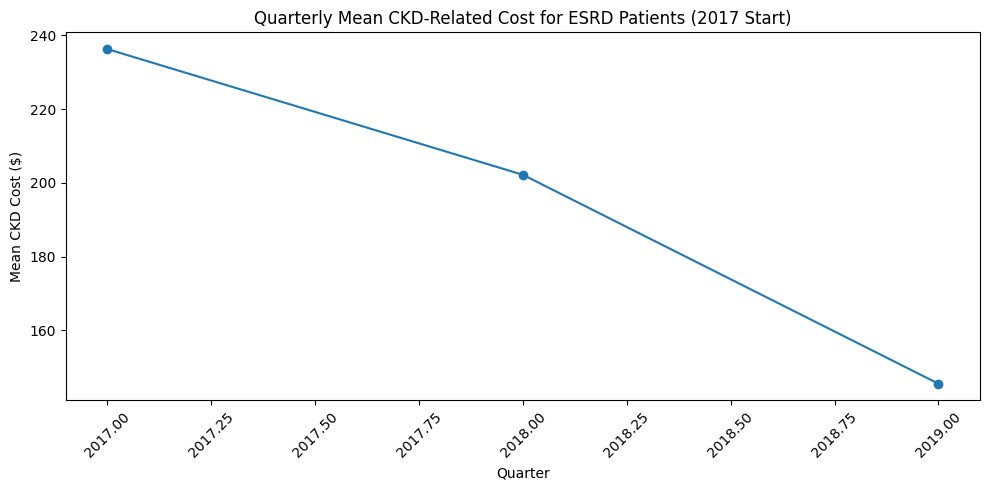

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_stage1_avg_pd["YEAR"], df_stage1_avg_pd["mean_ckd_cost"], marker="o")
plt.title("Quarterly Mean CKD-Related Cost for ESRD Patients (2017 Start)")
plt.xlabel("Quarter")
plt.ylabel("Mean CKD Cost ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Same thing but for all costs not just CKD claims

In [46]:
# Step 1: Get patients with CKD Stage 1 in 2017
df_ckd_2017 = (
    df_ckd_claims
    .filter(F.col("YEAR") == 2017)
    .select("ENROLID", "CKD_STAGE")
    .distinct()
)

df_stage1_2017 = df_ckd_2017.filter(F.col("CKD_STAGE") == "ESRD").select("ENROLID")

# Step 2: Filter all claims for those patients
df_stage1_claims = df_claims.join(df_stage1_2017, on="ENROLID", how="inner")

# Step 3: Add quarter label
df_stage1_claims = df_stage1_claims.withColumn(
    "quarter",
    F.concat_ws("Q", F.year("SVCDATE"), F.quarter("SVCDATE"))
)

# Step 4: Aggregate total cost per enrollee per quarter
df_quarterly_allcosts = (
    df_stage1_claims
    .groupBy("ENROLID", "quarter")
    .agg(F.sum("NETPAY").alias("quarterly_cost"))
)

# Step 5: Average across patients per quarter
df_avg_quarterly_allcosts = (
    df_quarterly_allcosts
    .groupBy("quarter")
    .agg(F.mean("quarterly_cost").alias("avg_cost"))
    .orderBy("quarter")
)

# Step 6: Convert to Pandas for plotting
df_avg_quarterly_allcosts_pd = df_avg_quarterly_allcosts.toPandas()


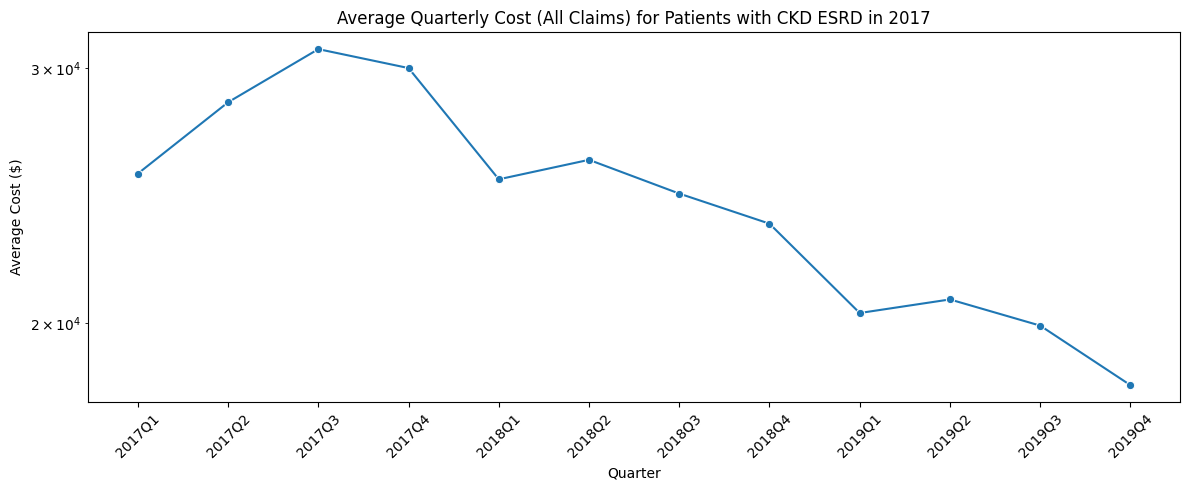

In [47]:
# Remove 2020Q1 from the Pandas dataframe before plotting
df_avg_all_costs_stage1 = df_avg_quarterly_allcosts_pd[
    (df_avg_quarterly_allcosts_pd["quarter"] > "2016Q4") &
    (df_avg_quarterly_allcosts_pd["quarter"] < "2020Q1")
]
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_avg_all_costs_stage1, x="quarter", y="avg_cost", marker="o")
plt.title("Average Quarterly Cost (All Claims) for Patients with CKD ESRD in 2017")
plt.ylabel("Average Cost ($)")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.yscale("log")  # Optional: log scale
plt.tight_layout()
plt.show()
